In [1]:
try:
    import keras
    import tensorflow
except:
    %pip install keras_preprocessing
    %pip install keras -qqq
    %pip install tensorflow -qqq
    %pip install pyserial -qqq
    %pip install matplotlib -qqq
    import keras
    import tensorflow
    import serial

2026-01-26 15:28:25.662659: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-26 15:28:25.662827: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-26 15:28:25.692461: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-26 15:28:26.682944: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
from matplotlib import pyplot as plt
import numpy as np
from IPython.display import clear_output
import time
import random as rd


In [3]:
import serial
serial.Serial()

Serial<id=0x7fd9840eef20, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)

In [4]:
%pip install pyserial -qqq


Note: you may need to restart the kernel to use updated packages.


In [5]:
from keras_preprocessing import image as img

In [6]:
from PIL import Image

In [7]:
import socket
import numpy as np
import matplotlib.pyplot as plt
import struct

## Conjunto de funções dedicadas a comunicação TCP/IP - FreeRTOS

In [8]:
def connect_to_server(server_ip, server_port,string):
    """Establishes a connection to the server and returns the socket."""
    client_socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    client_socket.connect((server_ip, server_port))
    #print(f"Connected to server at {server_ip}:{server_port} - {string}")
    #print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return client_socket
def send_message(client_socket, data):
    """Sends raw data to the server."""
    client_socket.sendall(data)

def receive_message(client_socket, data_size):
    """Receives raw data from the server."""
    data = client_socket.recv(data_size)  # Receive the data of the specified size
    #print("Received data.")
    return data

In [9]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
#        print(f'{bin(X[i][j])}',end=' ')

        print(f'{X[i][j]:01d}',end=' ')
    print()

In [10]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Bin[i][j] = rd.randint(1*1*(BitsPorSimbolo),1*4**(BitsPorSimbolo))
      Ain[i][j] = rd.randint(1*1*(BitsPorSimbolo),1*4**(BitsPorSimbolo))
  return [Ain,Bin]

In [11]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [12]:
def compar_matrix(M1,M2):
    for i in range(M1.shape[0]):
        for j in range(M1.shape[0]):
            if(M1[i][j]!=M2[i][j]):
                return 1
    return 0

In [13]:


def send2(Asyst,delay = 1/1000,string="none"):
    #print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here

    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =int(len(Asyst))        # Number of sine samples to send
    # Generate the sine wave (integer values)
    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT,string)
    # Send the sine wave data to the server (packed as binary)
    data_vec = Asyst
    data_vec_bytes = struct.pack(f'{NUM_SAMPLES}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    client_socket.close()


In [14]:
def matrix2vec(m):
    lin = m.shape[0]
    col = m.shape[1]
    vec = np.zeros(lin*col,dtype=int)
    k= 0
    for i in range(lin):
        for j in range(col):
            vec[k] = int(m[i][j])
            k+=1
    return vec
def matrix2vec(m,m0):
    return np.array(np.concat(([255,255],m.reshape(1,31*16)[0][0:],[173,218,255,255],m0.reshape(1,31*16)[0][0:],[173,218])),dtype=np.int16)

vnstat -l -i enp4s0


In [15]:
def recever2A(col =16,delay = 1/1000,string="None"):
    #print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # Define the parameters here
    lin = col
    #print(lin,col)
    SERVER_IP = "192.168.12.10"  # Change to your server's IP address
    SERVER_PORT = 7            # Change to your server's port number
    NUM_SAMPLES =256        # Number of sine samples to send
    # Generate the sine wave (integer values)
    # Connect to the server
    client_socket = connect_to_server(SERVER_IP, SERVER_PORT,string)
    data_vec = [0xea,0xea]
    data_vec_bytes = struct.pack(f'{2}i', *data_vec)
    send_message(client_socket, data_vec_bytes)
    raw_response = receive_message(client_socket, NUM_SAMPLES * 4)  # 4 bytes per integer
    received_data = np.array(struct.unpack(f'{NUM_SAMPLES}i', raw_response), dtype=np.int32)
    client_socket.close()
    return received_data.reshape(16,16)



In [16]:
i = 0
while(True):
    A,B = np.array(create_matrix(16,1))
    Asyst ,Bsyst = shiftMatrixSystolic(A,B)
    vec = matrix2vec(Asyst.T,Bsyst.T)
    ti = time.time()
    send2(vec,delay = 0,string="OPA")
    time.sleep(500e-6)
    Y = recever2A(col =16,delay =0,string="A*B")
    tf = time.time()
    print(f"{(tf-ti)},{i}\n")
    time.sleep(500e-6)
    i+=1
    break


0.0010883808135986328,0



In [17]:
i = 0
while(True):
    A,B = np.array(create_matrix(16,1))
    Asyst ,Bsyst = shiftMatrixSystolic(A,B)
    vec = matrix2vec(Asyst.T,Bsyst.T)
    ti = time.time()
    send2(vec,delay = 0,string="OPA")
    time.sleep(8*144e-6)
    Y = recever2A(col =16,delay =0,string="A*B")
    i+=1
    tf = time.time()
    print((tf-ti),i,'\n')
    time.sleep(2*144e-6)
    break


 


0.0016026496887207031 1 



In [18]:
from keras.preprocessing.image import img_to_array

# Visão de escalabilidade e requisitos

In [19]:
sizt =1024
sizek = 3
sizeSystolicCore = np.zeros(sizt)
sizeImagemProcessada = np.zeros(sizt)

#for i in range(sizek,sizt):
#    #(Imagem-1)**2==Systolic
#    sizeImagemProcessada[i-sizek] =i
#    sizeSystolicCore[i-sizek] = 2**(np.log2((i-sizek+1)**2))
#
#plt.figure(figsize=(10,10))
#desl = 7
#plt.yticks([2**(i+desl) for i in range(sizt-desl)])
#plt.stem(sizeImagemProcessada,sizeSystolicCore,markerfmt="^")
#plt.xlabel("Tamanho da Imagem")
#plt.ylabel("Requisito Systolic")

# FILTROS e IMAGEM

In [20]:
K1 = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
K1 = np.array([[1,1,1],[1,9,1],[1,1,1]])
#K1 = np.array([[0,0,0],[0,1,0],[0,0,0]])
#K1 = np.array([[1,1,1],[1,1,1],[1,1,1]])/2
K2 = np.array([[-1,0,-1],[-2,0,2],[-1,0,1]])
#K1 = np.array([[0,0,0],[0,1,0],[0,0,0]])
#K2=K1
M = np.array([[1,2,3,4],[4,5,6,4],[7,8,9,4],[3,6,0,1]])

M = np.array([[1,2,3],[4,5,6],[7,8,9]])
#K = np.array([[1,0],[0,-1]])
#K = np.array([[0,0],[0,1]])


In [21]:
path = "./Monalisa.webp"
image =plt.imread(path)

In [22]:

imga = img.load_img(
    path,
    target_size=(sizt,sizt),
    color_mode="grayscale",

)

In [23]:
image = imga.resize([sizt, sizt])



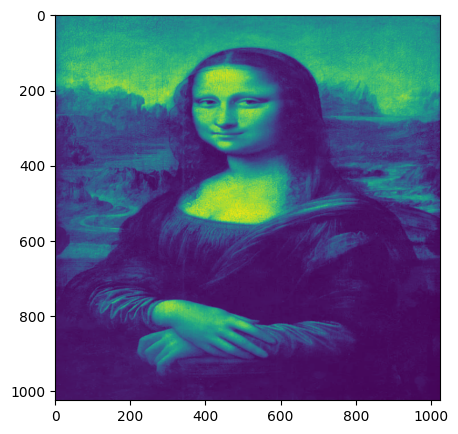

In [24]:
IMAG1 = img_to_array(image).reshape(sizt,sizt)
plt.figure(figsize=(5,5))
plt.imshow(IMAG1)
IMAG = M

In [25]:
def normalizeImage(image):
    size_row = image.shape[0]
    size_lin = image.shape[1]
    image_norm = np.zeros((size_lin,size_row),dtype=int)
    for i in range(size_lin):
        for j in range(size_row):
            if(image[i][j] > 32):
                image_norm[i][j] = 9
            else:
                image_norm[i][j] = 1
    return image_norm

In [26]:
max = IMAG1.max()

In [27]:
IMAG = np.array(((IMAG1)/max)*2**3,dtype=int)+1

In [28]:
IMAG.max()

np.int64(9)

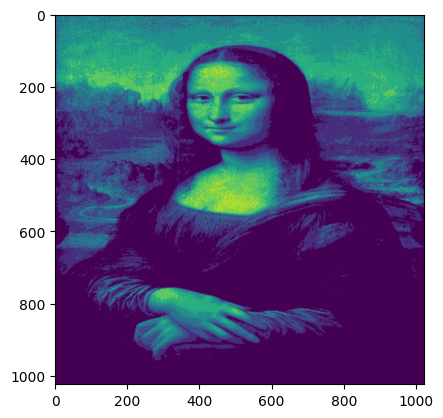

In [29]:
plt.imshow(IMAG)

In [30]:
IMAG

array([[3, 3, 3, ..., 4, 4, 4],
       [3, 3, 3, ..., 4, 4, 4],
       [3, 3, 3, ..., 3, 3, 3],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(1024, 1024))

In [31]:
def flatten_kernel(K):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada somente no kernel'''

    size = K.shape[0]
    outK = np.zeros((1,size**2))
    k = 0
    for i in range (size):
        for j in range(size):
        
            outK[0][k] = K[i][j]
            k+=1
    return outK

In [32]:
def inv_transform(M,sizeMinicial):
    "Inversão das transformações"
    size = int((sizeMinicial))
    Mout = np.zeros((size,size))
    print(size)

    k = 0
    for i in range(size):
        for j in range(size):
            Mout[i][j] = M[0][k]

            k+=1

    return Mout



In [33]:
def transform_matrix(M,Kern):
    ''''Esta função realizará as devidas conversões para transformar uma convolução em multiplicação de matrizes ela será aplicada matriz de entra'''
    sizeKernel  = Kern.shape[0] 
    sizel = M.shape[0]
    sizec = M.shape[1]
    Mout = np.zeros((sizeKernel**2,int((sizel-sizeKernel+1)**2)))
    k = 0
    for i in range(0,sizel-sizeKernel+1):
        for j in range(0,sizec-sizeKernel+1):
            '''Melhorias futuras'''
            X0 ,X1 ,X2 ,X3 ,X4 ,X5 ,X6 ,X7 ,X8 = M[i][j],M[i][j+1],M[i][j+2],M[i+1][j+0],M[i+1][j+1],M[i+1][j+2],M[i+2][j+0],M[i+2][j+1],M[i+2][j+2]
            Mout[0][k+0] = X0
            Mout[1][k+0] = X1
            Mout[2][k+0] = X2
            Mout[3][k+0] = X3
            Mout[4][k+0] = X4
            Mout[5][k+0] = X5
            Mout[6][k+0] = X6
            Mout[7][k+0] = X7
            Mout[8][k+0] = X8
            #X0 ,X1 ,X2 ,X3 = M[i][j],M[i][j+1],M[i+1][j],M[i+1][j+1]
            #Mout[0+0][k+0] = X0
            #Mout[0+1][k+0] = X1
            #Mout[0+2][k+0] = X2
            #Mout[0+3][k+0] = X3

            #print(X0,X1,X2,X3)
            k+=1
    return Mout

In [34]:
def normalizeMatrixSIZE(matrix,sizeTarget):
    matrixMout = np.zeros((sizeTarget,sizeTarget),dtype=int)
    size_row = matrix.shape[1]
    size_lin = matrix.shape[0]
    if(matrix.shape[0] ==1):
       # print("Kernel_transform detec")
       #Fazendo kernel**2 copias para maior deslocamneto no janelamento
        for i in range(size_row):
            for j in  range(size_row):
                matrixMout[0][j] = matrix[0][j]
                #matrixMout[i][j] = matrix[0][j]
                #print("Aqui",matrix[i][j])
    else:
        for i in range(size_lin):
            for j in  range(size_row):
                matrixMout[i][j] = matrix[i][j]
                #print("Aqui",matrix[i][j])
    return matrixMout
    


In [35]:
def conv2mult(sizeTarget, inputConv,inputK,debug='off'):
    '''Esta função realizá as transformações necessárias para converter a operação de convolução em uma multiplicação de matrizes'''
    Matrix_tranform = transform_matrix(inputConv,inputK)
    Kernel_transform = flatten_kernel(inputK)
    if(debug=='on'):
        print("Imagem new size:",Matrix_tranform.shape)
        print("Kernel new size:",Kernel_transform.shape)
    matrix_target_image=normalizeMatrixSIZE(matrix=Matrix_tranform,sizeTarget =sizeTarget)
    matrix_target_kernel=normalizeMatrixSIZE(matrix=Kernel_transform,sizeTarget=sizeTarget)
    return [matrix_target_kernel,matrix_target_image]

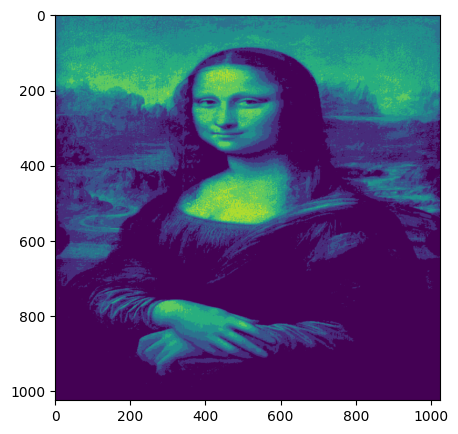

In [36]:
plt.figure(figsize=(5,5))
plt.imshow(IMAG)

In [37]:
def normalizeImage(image):
    size_row = image.shape[0]
    size_lin = image.shape[1]
    image_norm = np.zeros((size_lin,size_row),dtype=int)
    for i in range(size_lin):
        for j in range(size_row):
            if(image[i][j] > 4):
                image_norm[i][j] = 1
            else:
                image_norm[i][j] = 0
    return image_norm

In [38]:
#IMAG = normalizeImage(IMAG)

In [39]:
IMAG.max()

np.int64(9)

In [40]:
#plt.figure(figsize=(500,1000))
#plt.imshow(transform_matrix(IMAG,Kern=K).T)

In [41]:
requi = 2**int(np.log2((IMAG.shape[0]-sizek)**2)+1)
print("Requisito do multiplicador:", requi)

Requisito do multiplicador: 1048576


In [42]:
#A1@B1

## Kernel no novo domínio com expansão dos operandos

In [43]:
#plt.subplot(1,2,1)
#plt.imshow(A1)
#plt.subplot(1,2,2)
#plt.imshow(A2)

## Imagem no novo domínio com expansão dos operandos


In [44]:
##@plt.subplot(1,2,1)
##@plt.imshow(B1)
##@plt.subplot(1,2,2)
##@plt.imshow(B2)


#Resultado da Convolução no novo domínio com expansão dos operandos

In [45]:
#plt.figure(figsize=(10,10))
#plt.subplot(1,2,1)
#plt.imshow(Mout_vec1)
#plt.subplot(1,2,2)
#plt.imshow(Mout_vec2)
#plt.show()

#Resultado da Convolução no domínio base

In [46]:
def windows_slice(imagem,windows_size,imag_size,step=3):

    '''Esta função retornará uma pequena fatia da imagem base, dada uma posição relativa. Com o tamanho da unidade de mulltiplicação'''
    window_buffer = np.zeros((windows_size,windows_size))
    
    try:
        for k in range(windows_size):
             for h in range(windows_size):
                window_buffer[k][h] = imagem[windows_slice.posy_static+k][windows_slice.posx_static+h]
    except:
        print("Fora do limite da imagem, posx e posy < imag_size")
        windows_slice.posx_static = 0
        windows_slice.posy_static = 0
    windows_slice.posx_static +=step
    if(windows_slice.posx_static >= imag_size-windows_size-step-1):
        windows_slice.posx_static = 0
        windows_slice.posy_static +=step
    print(windows_slice.posx_static,windows_slice.posy_static)
    return (window_buffer,windows_slice.posy_static == imag_size-windows_size-1)


In [47]:
windows_slice.posx_static = 0
windows_slice.posy_static = 0

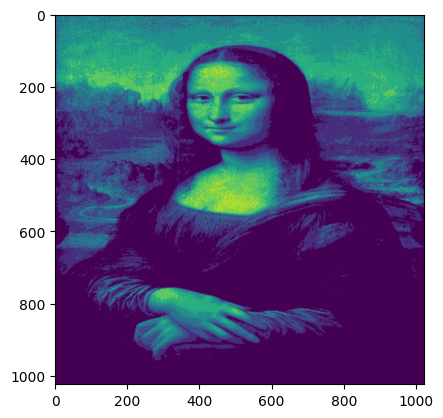

In [48]:
plt.imshow(IMAG)

In [49]:
windows_slice.posx_static = 0
windows_slice.posy_static = 0

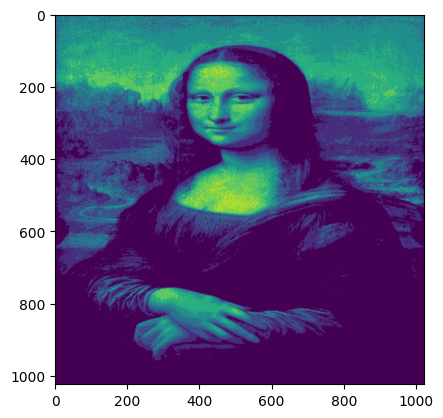

In [50]:
plt.imshow(IMAG)


In [51]:
def rebuild_image(windows_buffer_conv,size_imag,size_mult,windows_size,step=3):

    for k in range(size_mult):
     for h in range(size_mult):
        rebuild_image.window_buffer[rebuild_image.posy+k][rebuild_image.posx+h] = windows_buffer_conv[k][h]
    rebuild_image.posx +=step
    if(rebuild_image.posx >= size_imag-windows_size-step+2):
        
        if(rebuild_image.posx == size_mult and rebuild_image.posy == size_mult):
           rebuild_image.posy =size_mult
           rebuild_image.posy =size_mult
        else:   
            rebuild_image.posy +=step
            rebuild_image.posx  = 0

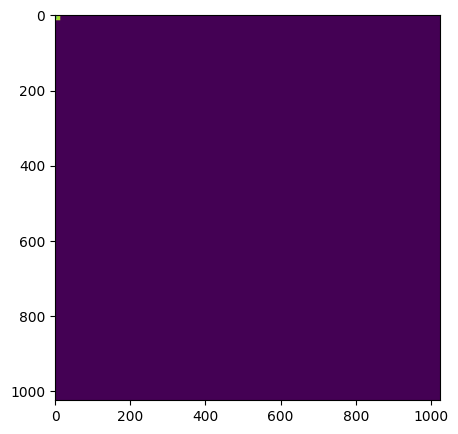

In [52]:
windows_size =16# Valor limite do Systolic da Arty A7
windows_slice.posx_static = 0
windows_slice.posy_static = 0
i = 0
rebuild_image.window_buffer = np.zeros((sizt,sizt))
rebuild_image.posy = 0
rebuild_image.posx = 0
plt.figure(figsize=((8,8)))
while(True):
    #time.sleep(1/30)
    (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt)
    A,B = conv2mult(sizeTarget=256,inputConv=windows_buffer,inputK=K1)
    ResultMult = A@B #ENtrada do SystolicCore-Arty A7 Limitada em 16x16-4Bit/Símbolo
    windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
    plt.imshow(windows_buffer_conv)
    plt.show()
    print(windows_buffer_conv.shape,A.shape,B.shape)
    rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size)
    clear_output(wait=True)
    break #Retire
    if(finish ):
        break
    i+=1
plt.figure(figsize=(5,5))
plt.imshow(rebuild_image.window_buffer)
plt.show()

# Ambiente de convolução no PC

In [53]:
K1 = np.ones((3,3))
K1[0][0] = 1
K1[1][0] = 2
K1[2][0] = 1
K1[0][2] = -1
K1[1][2] = -2
K1[2][2] = -1
K1[0][1] = 0
K1[2][1] = 0
K1[1][1] = 0
K1=K1
K1

array([[ 1.,  0., -1.],
       [ 2.,  0., -2.],
       [ 1.,  0., -1.]])

In [54]:
while(True):
    break
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((8,8)))
    while(True):
        print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
        Asyst=abs(A)#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        ResultMult = Asyst@Bsyst
        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        plt.subplot(1,2,1)
        plt.imshow(A)
        plt.subplot(1,2,2)

        plt.imshow(B)
        plt.show()
        print(windows_buffer_conv.shape,A.shape,B.shape)
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        clear_output(wait=True)
        if(finish ):
            break
        i+=1
        plt.figure(figsize=(10,10))
        plt.subplot(1,2,1)
        plt.imshow(rebuild_image.window_buffer)
        plt.subplot(1,2,2)
        plt.imshow(IMAG)
        plt.figure(figsize=(10,10))
        plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("kjhglsdgf")
            break
    break
    

In [55]:
while(True):
    break
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((8,8)))
    while(True):
        print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
        Asyst=abs(A)#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        ResultMult = Asyst@Bsyst
        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        clear_output(wait=True)
        if(finish ):
            break
        i+=1
        plt.figure(figsize=(10,10))
        plt.subplot(1,2,1)
        plt.imshow(rebuild_image.window_buffer)
        plt.subplot(1,2,2)
        plt.imshow(IMAG)
        plt.figure(figsize=(10,10))
        plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("kjhglsdgf")
            break
    break
    

In [56]:
while(True):
   
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((8,8)))
    while(True):
        print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
        Asyst=abs(A)#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        ResultMult = Asyst@Bsyst
        #time.sleep(50e-6)
        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        clear_output(wait=True)
        if(finish ):
            break
        i+=1
        if(False):
            plt.figure(figsize=(10,10))
            plt.subplot(1,2,1)
            plt.imshow(rebuild_image.window_buffer)
            plt.subplot(1,2,2)
            plt.imshow(IMAG)
            plt.figure(figsize=(10,10))
            plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("kjhglsdgf")
            break
    break

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(rebuild_image.window_buffer)
plt.subplot(1,2,2)
plt.imshow(IMAG)
plt.figure(figsize=(10,10))
plt.show()
if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
    print("finish")
    

Aqui 932 160
936 160
Imagem new size: (9, 16)
Kernel new size: (1, 9)


KeyboardInterrupt: 

<Figure size 800x800 with 0 Axes>

# Ambiente de convolução na FPGA


In [57]:
K1[0][0] = 0
K1[1][0] = 0
K1[2][0] = 0
K1[0][2] = 0
K1[1][2] = 0
K1[2][2] = 0
K1[0][1] = 0
K1[2][1] = 0
K1[2][2] = 0
K1[1][1] = 1

In [58]:
K1

array([[0., 0., 0.],
       [0., 1., 0.],
       [0., 0., 0.]])

In [59]:
K1 = np.zeros((3,3))*1
K1[0][0] = -1 +5
K1[0][1] = -2 +5
K1[0][2] = -1 +5

K1[2][0] = 1+5
K1[2][1] = 2+5
K1[2][2] = 1+5

K1=K1
K1

array([[4., 3., 4.],
       [0., 0., 0.],
       [6., 7., 6.]])

In [60]:
debug = False

In [61]:
plt.set_cmap('nipy_spectral')
while(True):
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((5,5)))
    k=0
    while(True):
        k+=1
        #print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='off')
        Asyst=abs(A)#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        M_p = shiftMatrixSystolic(Asyst,Bsyst)
        vec = matrix2vec(M_p[0].T,M_p[1].T)
        send2(vec,delay = 0,string="OPA")
        time.sleep(100e-6)
        ResultMult = recever2A(col =16,delay =0,string="A*B")
        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        
        if(finish ):
            break
        i+=1
        if(i%((1024))==1 and debug):
            #print(windows_buffer_conv)
            clear_output(wait=True)
            plt.figure(figsize=(8,8))
            plt.subplot(1,2,1)
            plt.imshow(rebuild_image.window_buffer[0:windows_slice.posx_static][0:windows_slice.posy_static],cmap="inferno")
            #plt.imshow(rebuild_image.window_buffer,cmap="hot")
            plt.subplot(1,2,2)
            plt.imshow(IMAG,cmap="inferno")
            plt.figure(figsize=(8,8))
            
            plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("finish")
            break
    break

    #
    #clear_output(wait=True)
    #plt.figure(figsize=(10,10))
    #plt.subplot(1,2,1)
    #plt.imshow(rebuild_image.window_buffer[0:windows_slice.posx_static][0:windows_slice.posy_static])
    #plt.subplot(1,2,2)
    #plt.imshow(IMAG)
    #plt.figure(figsize=(10,10))
    #plt.show()
    #break
    #time.sleep(1)

    #1m26s
    #1m30s

4 0
4
8 0
4
12 0
4
16 0
4
20 0
4
24 0
4
28 0
4
32 0
4
36 0
4
40 0
4
44 0
4
48 0
4
52 0
4
56 0
4
60 0
4
64 0
4
68 0
4
72 0
4
76 0
4
80 0
4
84 0
4
88 0
4
92 0
4
96 0
4
100 0
4
104 0
4
108 0
4
112 0
4
116 0
4
120 0
4
124 0
4
128 0
4
132 0
4
136 0
4
140 0
4
144 0
4
148 0
4
152 0
4
156 0
4
160 0
4
164 0
4
168 0
4
172 0
4
176 0
4
180 0
4
184 0
4
188 0
4
192 0
4
196 0
4
200 0
4
204 0
4
208 0
4
212 0
4
216 0
4
220 0
4
224 0
4
228 0
4
232 0
4
236 0
4
240 0
4
244 0
4
248 0
4
252 0
4
256 0
4
260 0
4
264 0
4
268 0
4
272 0
4
276 0
4
280 0
4
284 0
4
288 0
4
292 0
4
296 0
4
300 0
4
304 0
4
308 0
4
312 0
4
316 0
4
320 0
4
324 0
4
328 0
4
332 0
4
336 0
4
340 0
4
344 0
4
348 0
4
352 0
4
356 0
4
360 0
4
364 0
4
368 0
4
372 0
4
376 0
4
380 0
4
384 0
4
388 0
4
392 0
4
396 0
4
400 0
4
404 0
4
408 0
4
412 0
4
416 0
4
420 0
4
424 0
4
428 0
4
432 0
4
436 0
4
440 0
4
444 0
4
448 0
4
452 0
4
456 0
4
460 0
4
464 0
4
468 0
4
472 0
4
476 0
4
480 0
4
484 0
4
488 0
4
492 0
4
496 0
4
500 0
4
504 0
4
508 0
4
512 0
4
51

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

<Figure size 500x500 with 0 Axes>

# Ambiente de convolução no PC

In [ ]:
K1

array([[4., 3., 4.],
       [0., 0., 0.],
       [6., 7., 6.]])

In [ ]:
while(True):
    windows_size =6# Valor limite do Systolic da Arty A7
    step =(windows_size-2)#(windows_size-2)Máximo deslocamento da matriz igual ao tamanho do kernel
    windows_slice.posx_static = 0
    windows_slice.posy_static = 0
    i = 0
    rebuild_image.window_buffer = np.zeros((sizt,sizt))
    rebuild_image.posy = 0
    rebuild_image.posx = 0
    plt.figure(figsize=((8,8)))
    k=0
    while(True):
        k+=1
        #print("Aqui",windows_slice.posx_static,windows_slice.posy_static)
        #time.sleep(1/60)
        (windows_buffer,finish) = windows_slice(imagem=IMAG,windows_size=windows_size,imag_size=sizt,step=step)

        sizeTarget = int(np.log2((windows_buffer.shape[0]-sizek+1)**2))
        A,B= conv2mult(sizeTarget=2**sizeTarget,inputConv=windows_buffer,inputK=K1,debug='on')
        Asyst=abs(A)#Problemas no envio do kernel com zeros
        Asyst
        Bsyst = B#normalização de 4 bits
        M_p = shiftMatrixSystolic(Asyst,Bsyst)

        vec = matrix2vec(M_p[0].T,M_p[1].T)

        send2(vec,delay = 0,string="OPA")
        #send(M_p[0],delay = 1/fdelay,string="OPA")
        #time.sleep(2)
        #send(M_p[1],delay = 1/fdelay,string="OPB")
        time.sleep(50e-6)
        ResultMult = Asyst@Bsyst

        
        windows_buffer_conv = inv_transform(ResultMult,sizeMinicial = (windows_size-sizek+1))
        #print(windows_buffer_conv)
        rebuild_image(windows_buffer_conv,sizt,windows_buffer_conv.shape[0],windows_size,step=step)
        
        if(finish ):
            break
        i+=1
        if(False):
            plt.figure(figsize=(10,10))
            plt.subplot(1,2,1)
            plt.imshow(rebuild_image.window_buffer)
            plt.subplot(1,2,2)
            plt.imshow(IMAG)
            plt.figure(figsize=(10,10))
            plt.show()
        if(windows_slice.posx_static >= 0 and windows_slice.posy_static >= sizt-windows_size):
            print("finish")
            break


    
    clear_output(wait=True)
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(rebuild_image.window_buffer)
    plt.subplot(1,2,2)
    plt.imshow(IMAG)
    plt.figure(figsize=(10,10))
    plt.show()
    break
    #time.sleep(1)

    

4 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
8 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
12 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
16 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
20 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
24 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
28 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
32 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
36 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
40 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
44 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
48 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
52 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
56 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
60 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
64 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
68 0
Imagem new size: (9, 16)
Kernel new size: (1, 9)
4
72 0
Imagem new size: (9, 16)
Kernel new size: (1,

OSError: [Errno 99] Cannot assign requested address

<Figure size 800x800 with 0 Axes>

In [104]:
A,B = np.array(create_matrix(16,1))
Asyst ,Bsyst = shiftMatrixSystolic(A,B)
vec = matrix2vec(Asyst.T,Bsyst.T)
ti = time.time_ns()
send2(vec,delay = 0,string="OPA")
tf = time.time_ns()
time.sleep(50e-6)
Y = recever2A(col =16,delay =0,string="A*B")

print((tf-ti),'\n')
t_fpga = tf-ti
time.sleep(50e-6)



 


599580 



In [62]:
def software_mult(A,B,clock=333e+6):
    size = A.shape[0]
    C = np.zeros((size,size))
    for i in range(size):
        for j in range(size):
            sum_= 0
            for k in range(size):
                time.sleep(1/clock)
                sum_ += A[i][k]*B[k][j]
            C[i][j] = sum_
            #time.sleep(1/clock)
    return C

In [63]:
A,B=create_matrix(16,1)



In [64]:
software_mult(A,B,clock=333e+6);

In [65]:
ti = time.time_ns()
software_mult(A,B,clock=333e+6);
tf = time.time_ns()
(tf-ti)*1e-9

0.205001914

In [81]:
ti = time.time_ns()
A@B;
tf = time.time_ns()
tf-ti

39920

In [105]:
debug =False
A,B=create_matrix(16,2)
ti = time.time_ns()
if(debug):
    C = software_mult(A,B)
else:
    C=A@B
tf = time.time_ns()
t_pc = tf-ti
print(f"{t_fpga:}ns,  {t_pc:}ns,    {(t_pc/t_fpga)**(-1):}ns  {abs(t_fpga-t_pc)}")

599580ns,  39670ns,    15.114192084698765ns  559910
